In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def readImageAndTimes():
    filenames = ["../Images/HDR/-4.jpg", "../Images/HDR/-2.jpg", "../Images/HDR/+2.jpg", "../Images/HDR/+4.jpg"]
    
    #List of exposure times.
    times = np.array([1/30.0, 0.25, 2.5, 15.0], dtype=np.float32)

    #Read images
    images = []
    for file in filenames:
        im = cv.imread(file)
        im = cv.cvtColor(im, cv.COLOR_BGR2RGB)
        images.append(im)


    return images, times

- Align Images.

In [3]:
images, times = readImageAndTimes()

#Align.
alignMTB = cv.createAlignMTB()
alignMTB.process(images, images)

-  Estimate camera response time.

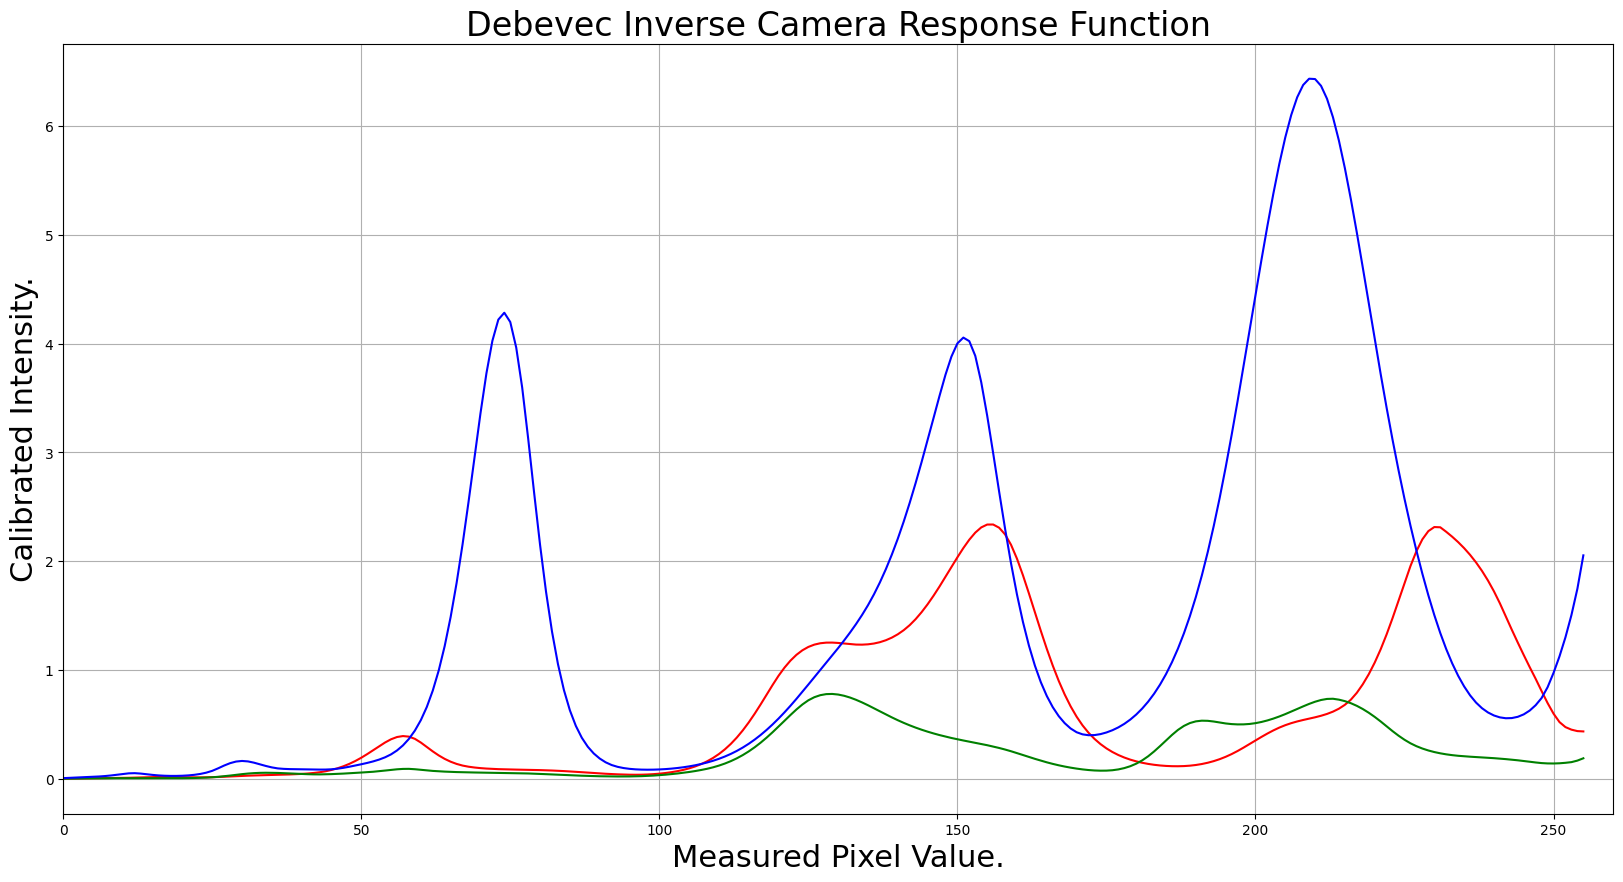

In [4]:
#Find Camera Response Time (RFT)
calibrateDebevec = cv.createCalibrateDebevec()
responseDebevec = calibrateDebevec.process(images, times)

#Plot RFT.
x = np.arange(256, dtype=np.uint8)
y = np.squeeze(responseDebevec)

ax = plt.figure(figsize=(20, 10))
plt.title("Debevec Inverse Camera Response Function", fontsize=24)
plt.xlabel("Measured Pixel Value.", fontsize=22)
plt.ylabel("Calibrated Intensity.", fontsize=22)
plt.xlim([0, 260])
plt.grid()
plt.plot(x, y[:, 0], 'r', x, y[:, 1], 'g', x, y[:, 2], 'b');

- Merge Exposure into an HDR Image.

In [5]:
mergeDebevec = cv.createMergeDebevec()
hdrDebevec = mergeDebevec.process(images, times, responseDebevec)

- Tonemapping.

[ WARN:0@56.857] global matrix_expressions.cpp:1333 assign OpenCV/MatExpr: processing of multi-channel arrays might be changed in the future: https://github.com/opencv/opencv/issues/16739


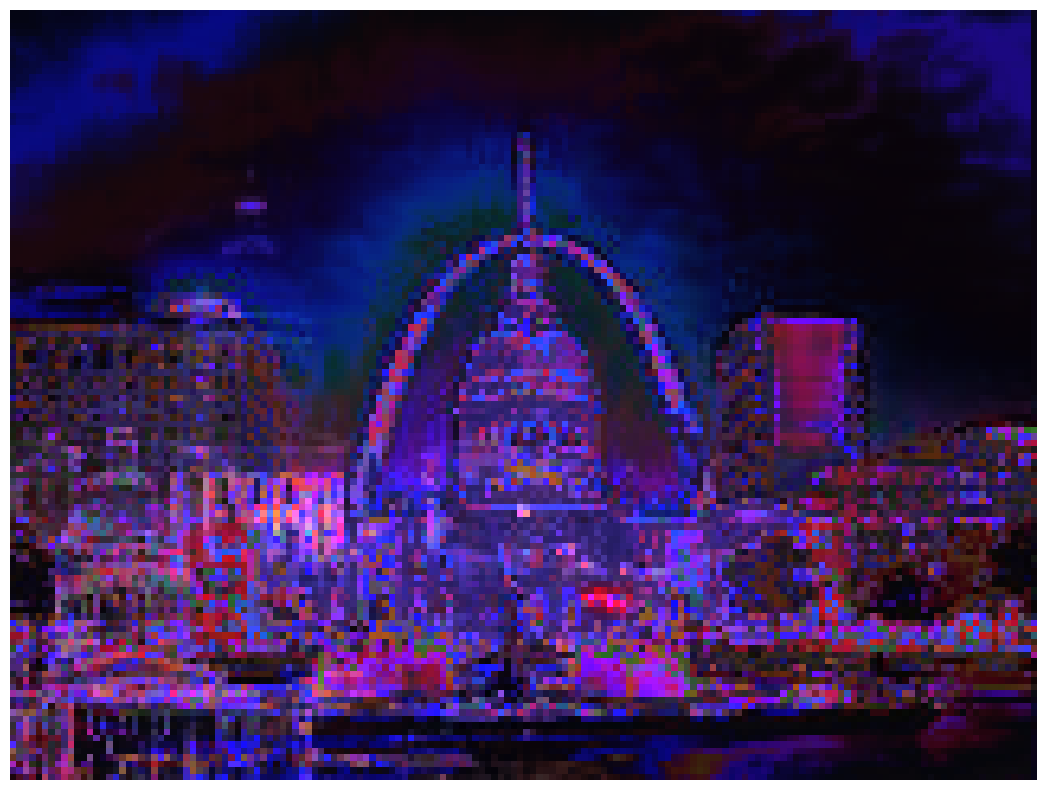

In [6]:
#Tonemap using Drago's method to obtain 24-bit color image.
tonemapDrago = cv.createTonemapDrago(1.0, 0.7)
ldrDrago = tonemapDrago.process(hdrDebevec)
ldrDrago = 3 * ldrDrago

plt.figure(figsize=(20, 10));plt.imshow(np.clip(ldrDrago, 0, 1));plt.axis('off');